In [47]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

/kaggle/input/datasets/murtazaabdullah2010/beans-classification-slovak-aoi-2026/sample_output(2).csv
/kaggle/input/datasets/murtazaabdullah2010/beans-classification-slovak-aoi-2026/train_data(2).csv
/kaggle/input/datasets/murtazaabdullah2010/beans-classification-slovak-aoi-2026/test_data(1).csv


In [48]:
train_ds =pd.read_csv("/kaggle/input/datasets/murtazaabdullah2010/beans-classification-slovak-aoi-2026/train_data(2).csv")
test_ds =pd.read_csv("/kaggle/input/datasets/murtazaabdullah2010/beans-classification-slovak-aoi-2026/test_data(1).csv")
sample_sub =pd.read_csv("/kaggle/input/datasets/murtazaabdullah2010/beans-classification-slovak-aoi-2026/sample_output(2).csv")

In [49]:
train_ds

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,58778,968.674,329.370047,227.650499,1.446823,0.722693,59726,273.566215,0.719305,0.984128,0.787172,0.830574,0.005604,0.001645,0.689853,0.998096,BARBUNYA
1,199021,1747.665,705.409896,364.768538,1.933856,0.855924,202063,503.389916,0.783763,0.984945,0.818827,0.713613,0.003544,0.000567,0.509244,0.984805,BOMBAY
2,175717,1585.869,593.695292,380.322431,1.561031,0.767873,178427,473.000881,0.802207,0.984812,0.877989,0.796706,0.003379,0.000840,0.634741,0.990851,BOMBAY
3,38273,704.621,242.712362,200.951906,1.207813,0.560813,38580,220.750305,0.790601,0.992043,0.968704,0.909514,0.006342,0.002677,0.827216,0.999122,SEKER
4,45030,842.585,343.632530,168.215351,2.042813,0.871991,45623,239.445143,0.630761,0.987002,0.797048,0.696806,0.007631,0.001110,0.485538,0.991864,HOROZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9522,35494,687.266,246.854646,183.614599,1.344417,0.668384,35872,212.584958,0.725048,0.989463,0.944311,0.861175,0.006955,0.002360,0.741622,0.997049,DERMASON
9523,157579,1512.321,558.993800,362.314853,1.542840,0.761508,159950,447.923893,0.710933,0.985177,0.865805,0.801304,0.003547,0.000902,0.642088,0.990639,BOMBAY
9524,39183,721.153,254.159122,196.589969,1.292839,0.633806,39567,223.359229,0.753766,0.990295,0.946788,0.878816,0.006486,0.002387,0.772318,0.998483,SEKER
9525,43395,769.000,284.958030,194.526111,1.464883,0.730747,43780,235.057929,0.816371,0.991206,0.922140,0.824886,0.006567,0.001875,0.680437,0.996761,SIRA


In [50]:
X_cols =[col for col in train_ds.columns if col !="Class"]

In [51]:
train_ds.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,9527.000000,9527.000000,9527.000000,9527.000000,9527.000000,9527.000000,9527.000000,9527.000000,9527.000000,9527.000000,9527.000000,9527.000000,9527.000000,9527.000000,9527.000000,9527.000000
mean,53001.552010,854.980102,320.041970,202.189669,1.583395,0.750553,53719.500577,252.964362,0.749527,0.987172,0.873335,0.799938,0.006565,0.001718,0.643765,0.995085
std,29295.588539,214.303340,85.802635,44.865726,0.248487,0.092859,29747.735452,59.102201,0.049075,0.004656,0.059904,0.062166,0.001126,0.000599,0.099740,0.004374
min,20420.000000,524.736000,183.601165,122.512653,1.036423,0.262774,20684.000000,161.243764,0.555315,0.919246,0.489618,0.645368,0.002778,0.000564,0.416499,0.947687
25%,36361.500000,703.404500,253.150567,175.933833,1.430343,0.714992,36731.000000,215.167144,0.718416,0.985753,0.831992,0.762263,0.005910,0.001153,0.581045,0.993737
50%,44725.000000,795.840000,296.910412,192.401403,1.549989,0.764043,45285.000000,238.632853,0.759424,0.988316,0.883267,0.801448,0.006648,0.001691,0.642320,0.996410
75%,61076.000000,974.032500,376.625190,216.377277,1.707422,0.810544,62008.500000,278.862652,0.786944,0.990036,0.917154,0.834738,0.007267,0.002179,0.696787,0.997895
max,254616.000000,1985.370000,738.860153,460.198497,2.388873,0.908167,263261.000000,569.374358,0.866195,0.994677,0.990685,0.981611,0.010451,0.003665,0.963560,0.999733


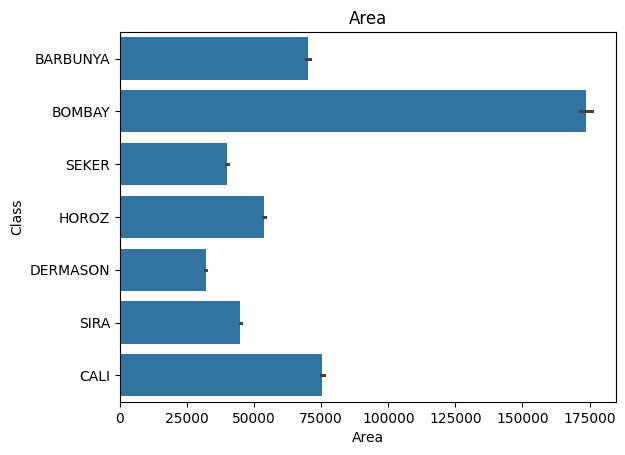

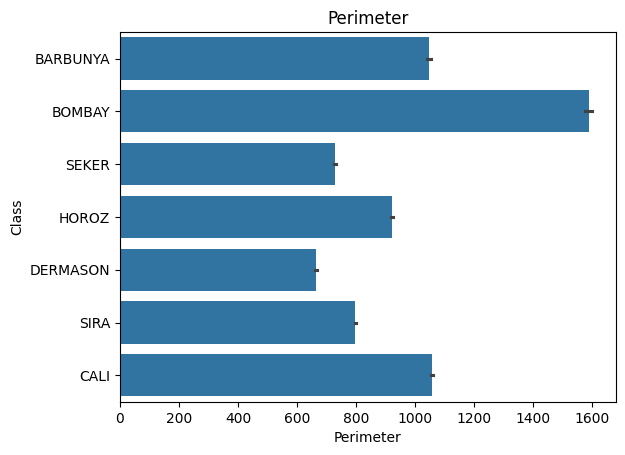

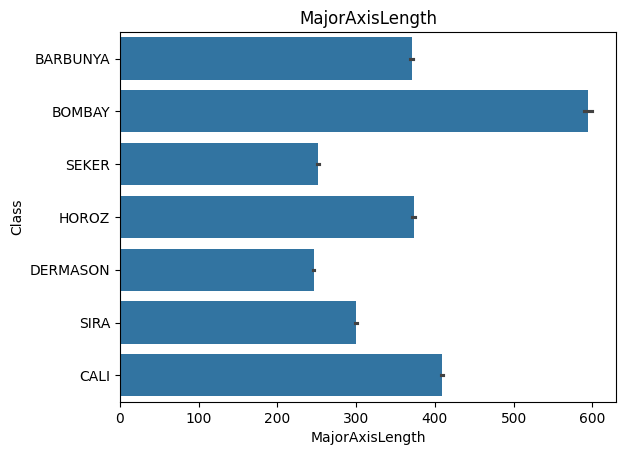

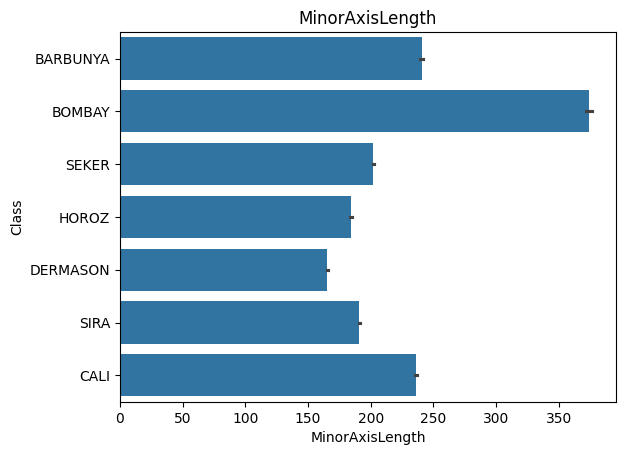

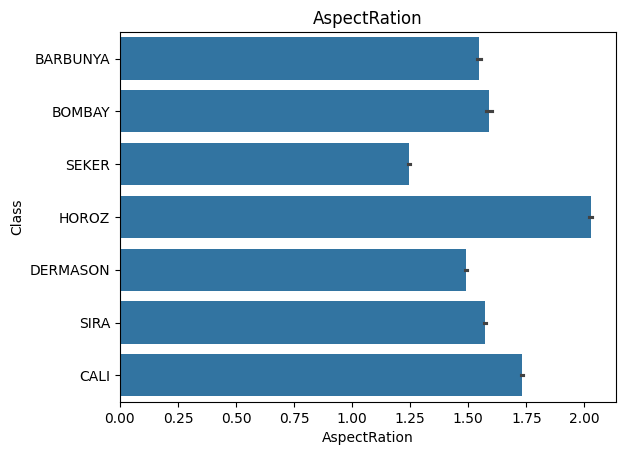

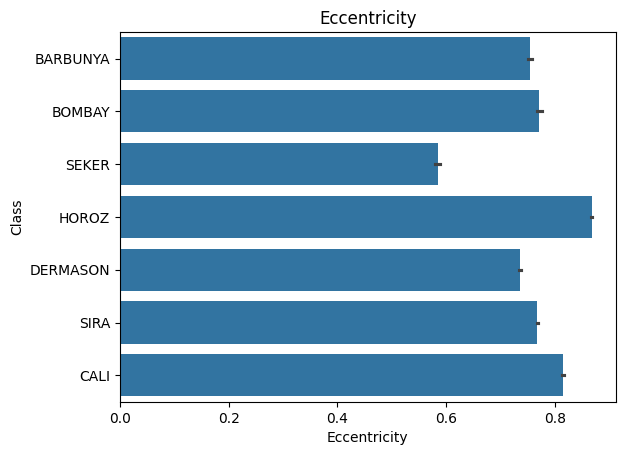

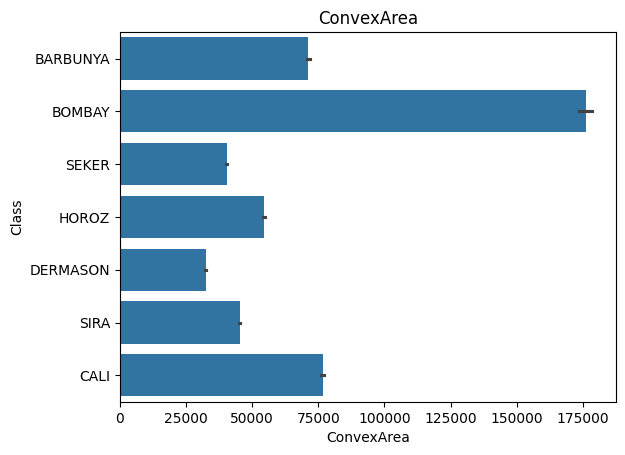

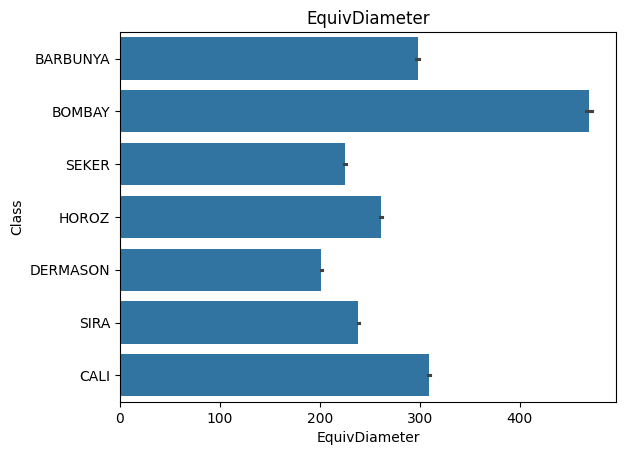

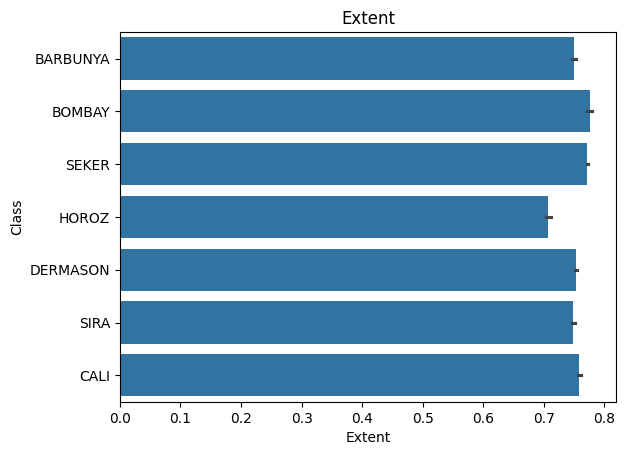

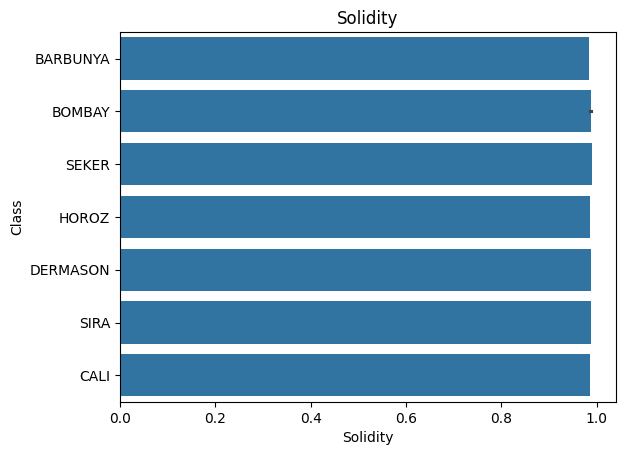

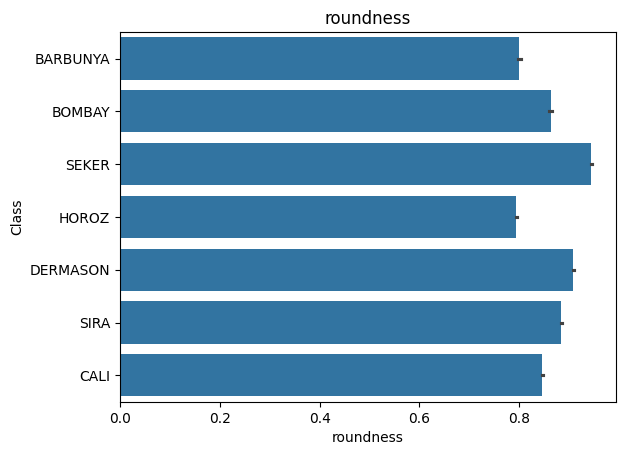

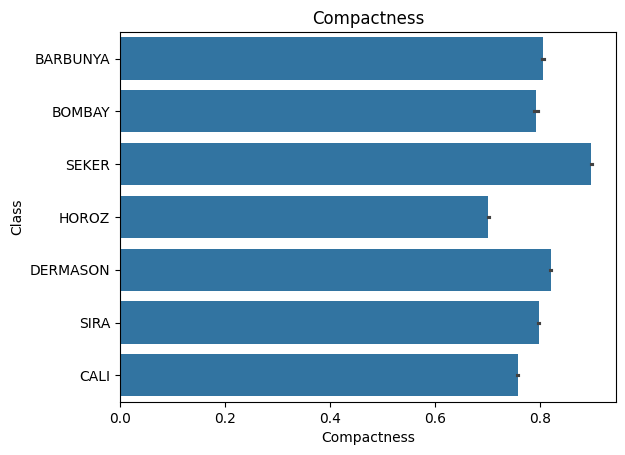

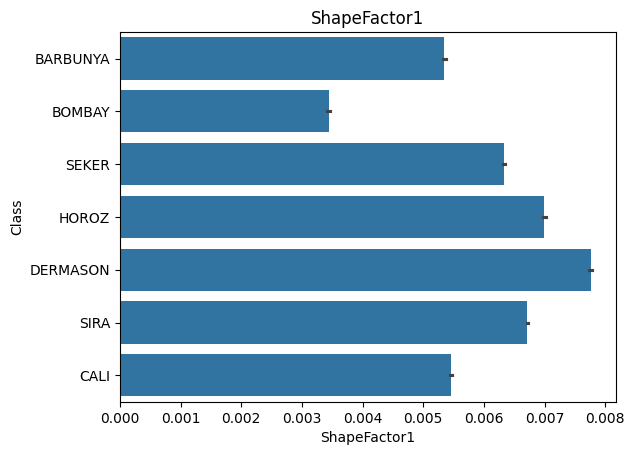

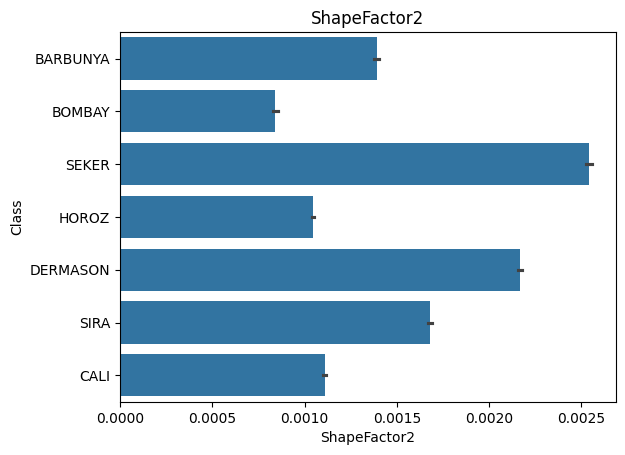

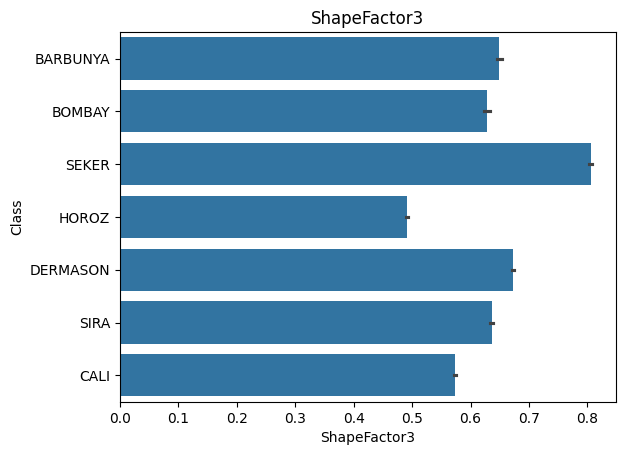

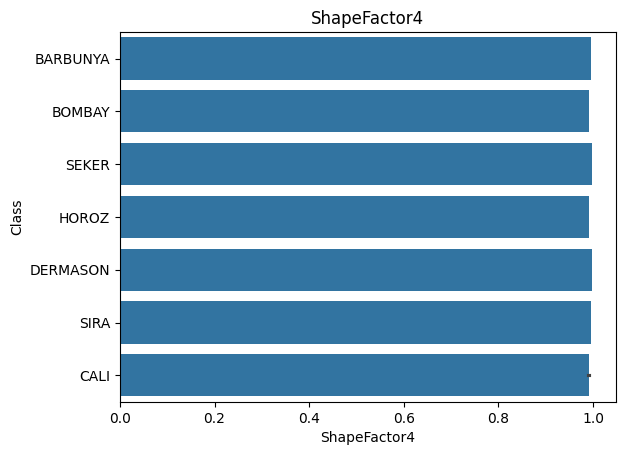

In [52]:
for col in X_cols:
    sns.barplot(data =train_ds,x = col, y="Class")
    plt.title(col)
    plt.show()

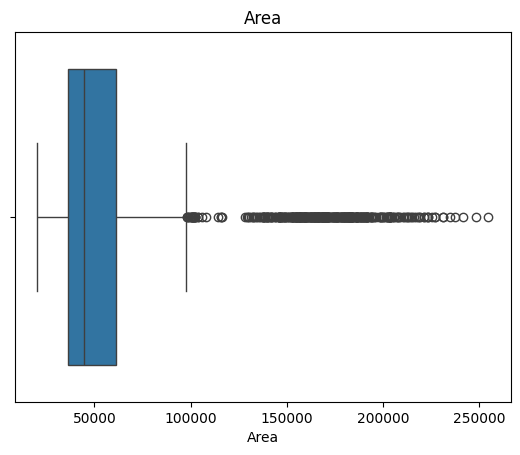

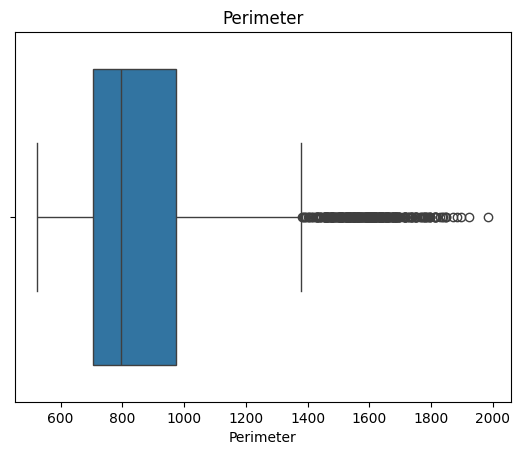

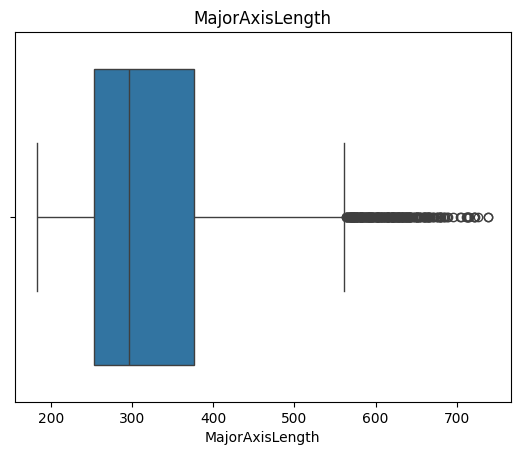

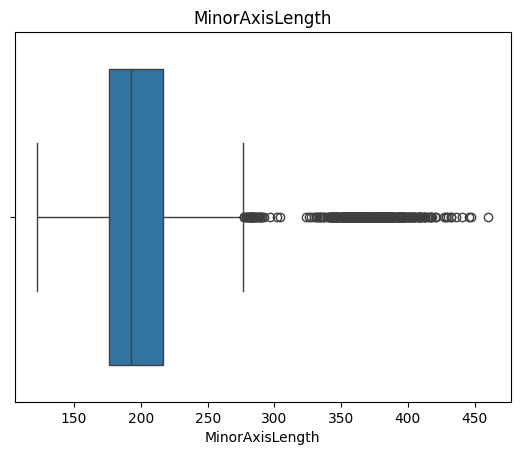

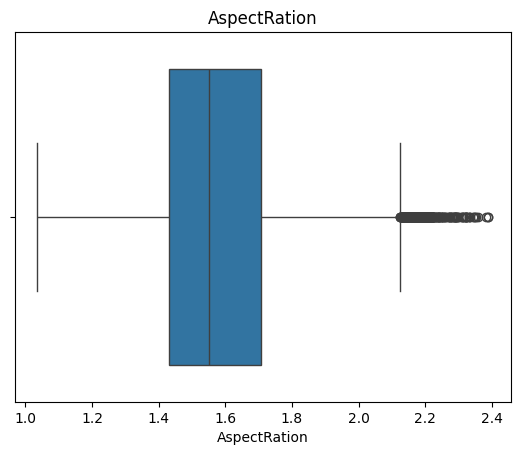

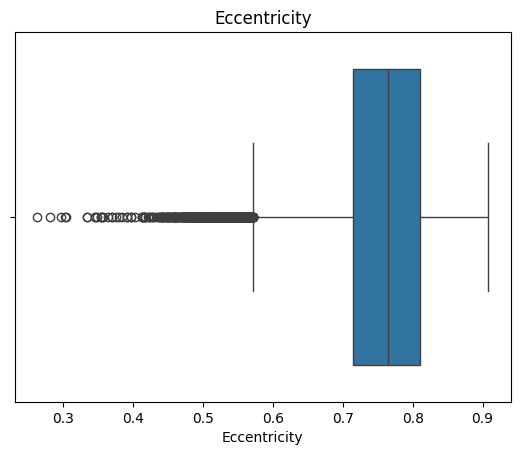

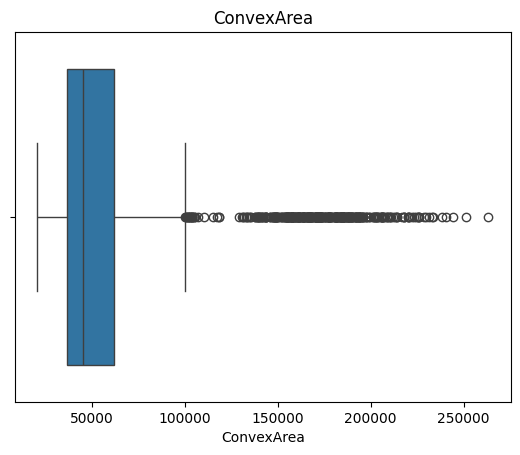

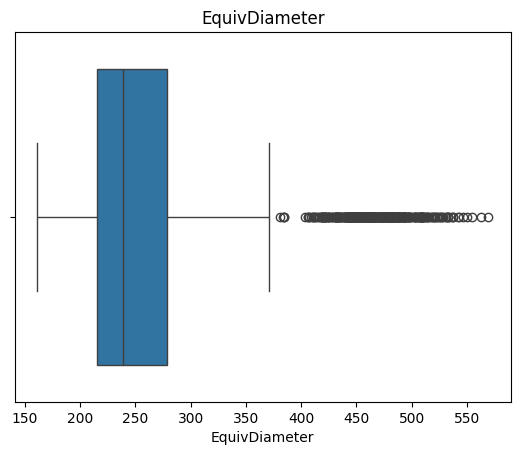

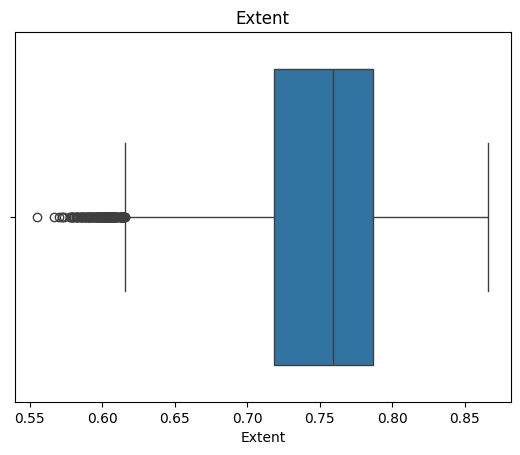

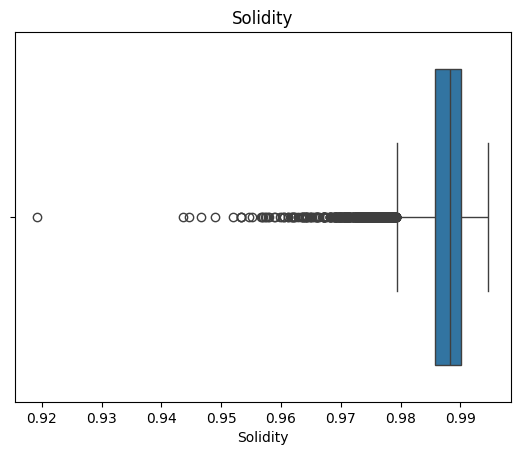

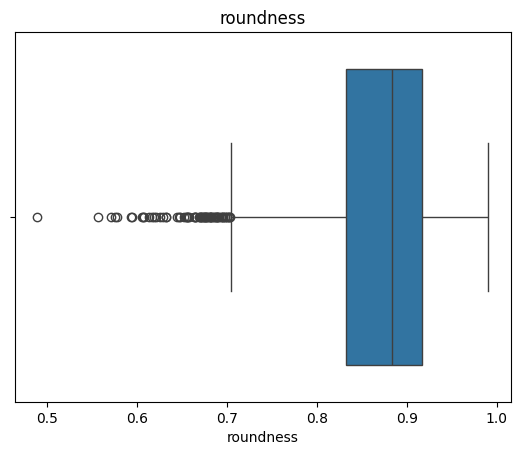

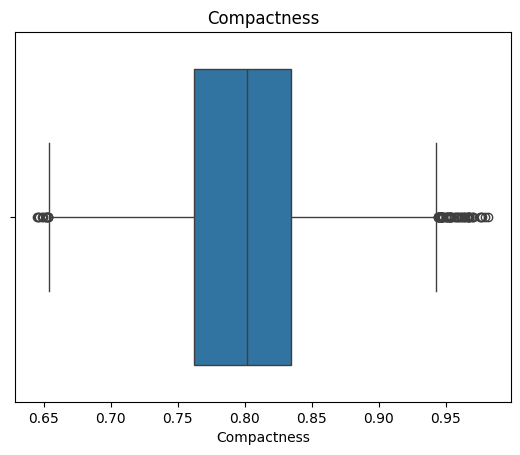

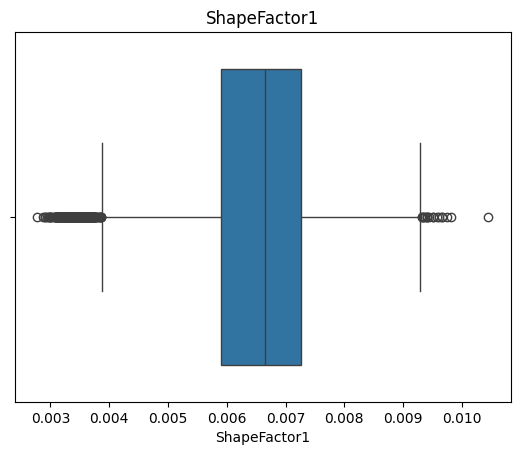

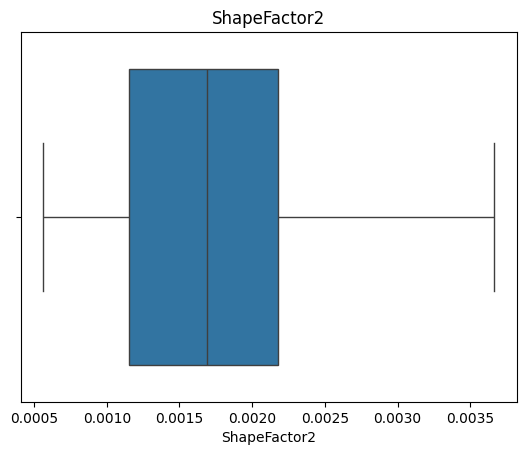

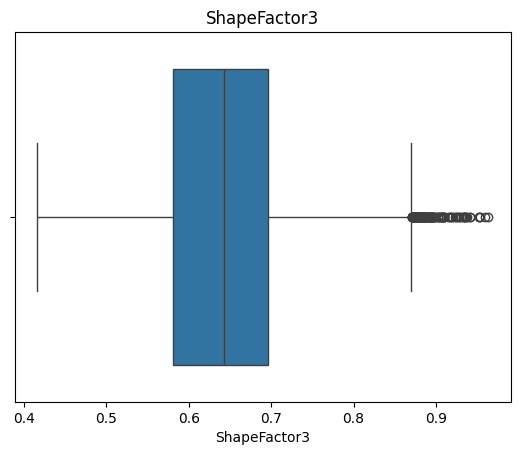

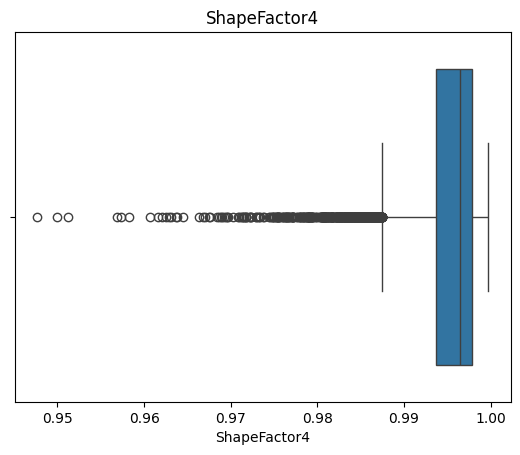

In [53]:
for col in X_cols:
    sns.boxplot(data =train_ds,x = col)
    plt.title(col)
    plt.show()

<Axes: >

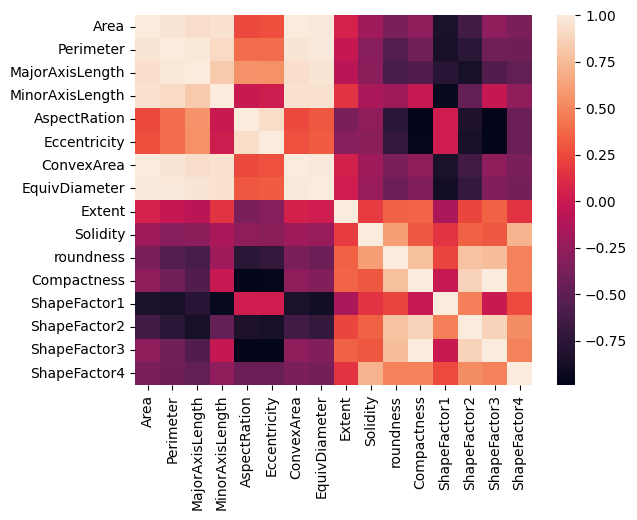

In [54]:
sns.heatmap(train_ds[X_cols].corr())

In [55]:
train_ds[X_cols].isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
dtype: int64

In [56]:
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler().fit(train_ds[X_cols])
train_ds[X_cols] = scaler.transform(train_ds[X_cols])
test_ds[X_cols] = scaler.transform(test_ds[X_cols])

In [57]:
from xgboost import XGBClassifier
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder().fit(train_ds[["Class"]])
train_ds["Class"] = encoder.transform(train_ds[["Class"]).ravel()
model = XGBClassifier(n_estimators=1000,max_depth=6).fit(  train_ds[X_cols], train_ds["Class"])
pred = model.predict(test_ds[X_cols])
sample_sub["answer"] = encoder.inverse_transform(
    pred.reshape(-1, 1)
).ravel()

In [58]:
sample_sub

,subtaskID,datapointID,answer
0,1,0,CALI
1,1,1,SEKER
2,1,2,SEKER
3,1,3,DERMASON
4,1,4,CALI
...,...,...,...
4079,1,4079,HOROZ
4080,1,4080,SIRA
4081,1,4081,DERMASON
4082,1,4082,DERMASON


In [60]:
sample_sub.to_csv("task1.2.csv",index= False)